In [1]:
!python ~/STEER/diffusers/exchange_scripts/generate_samples.py \
    --lam 1.05 \
    --steer-path "images/steer_tester" \
    --tsr-path "images/tsr_tester"

Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.
Loading pipeline components...: 100%|████████████| 9/9 [00:12<00:00,  1.44s/it]
Loaded 5 prompts
[tsr] skipping idx=0 (already exists at images/tsr_tester/lam1p050/00000.png)
[tsr] skipping idx=1 (already exists at images/tsr_tester/lam1p050/00001.png)
[tsr] skipping idx=2 (already exists at images/tsr_tester/lam1p050/00002.png)
[tsr] skipping idx=3 (already exists at images/tsr_tester/lam1p050/00003.png)
[tsr] skipping idx=4 (already exists at images/tsr_tester/lam1p050/00004.png)
TSR generation complete.
i=0 pair=(0,1) lam_t=1.04980 lam_s=1.08301 tsr_diff=0.000000 log_ratio=-0.0000 accept=1.0000 swapped=True
i=0 pair=(2,3) lam_t=1.11719 lam_s=1.15039 tsr_diff=0.000000 log_ratio=-0.0000 ac

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

/n/home00/zoewu/.conda/envs/diffusers/lib/python3.10/site-packages/torch/utils/data/dataloader.py:626: UserWarning: This DataLoader will create 12 worker processes in total. Our suggested max number of worker in current system is 8, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Computing real image features...


100%|██████████| 1/1 [00:00<00:00,  1.63it/s]


Real features computed from 5 images.



...

[tsr]  lam=1.050  FID=232.6199  CLIP=31.6082


CLIP lam=1.1: 100%|██████████| 5/5 [00:00<00:00, 19.65it/s]


[tsr]  lam=1.100  FID=226.5153  CLIP=31.6906


CLIP lam=1.05: 100%|██████████| 5/5 [00:00<00:00, 19.94it/s]


[steer_4]  lam=1.050  FID=221.9084  CLIP=31.6380


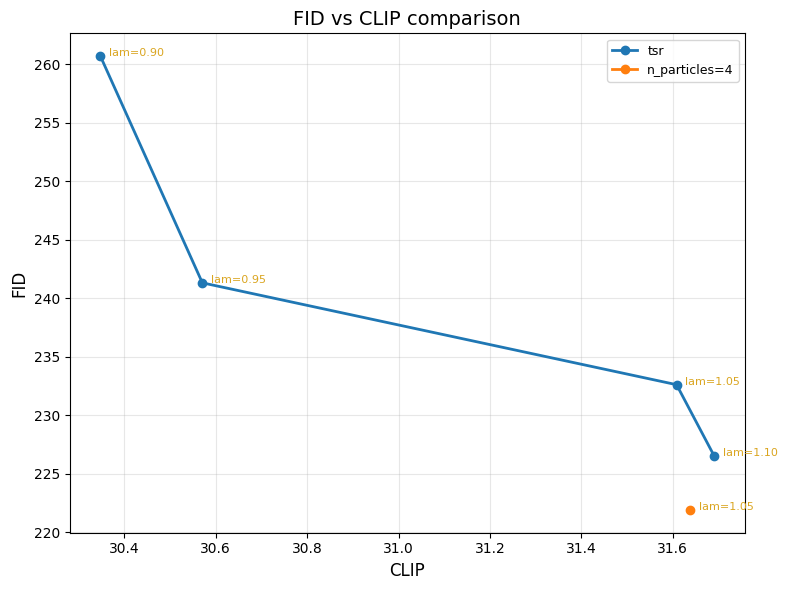

In [2]:
import sys
sys.path.append('~/STEER')  # or use os.path.expanduser('~/STEER')

import importlib.util
import os

path = os.path.expanduser('~/STEER/diffusers/exchange_scripts/fid.py')
spec = importlib.util.spec_from_file_location("generate_samples", path)
module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(module)

compute_sweep = module.compute_sweep

import os 
from pathlib import Path

tsr_results = compute_sweep(
    n_particles_list=[4],
    device="cuda",
    target_indices=[],
    index_until=5,
    tsr_dir=Path("images/tsr_tester"),
    steer_dir=Path("images/steer_tester"),        # fix kwarg name
)